In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:,.2f}".format)


In [2]:
DATA_PATH = Path("../data/raw")

In [6]:
accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")
support_ticket = pd.read_csv("ravenstack_support_tickets.csv")
churn_events = pd.read_csv("ravenstack_churn_events.csv")

In [4]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [39]:
subscriptions.head()





,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [15]:
def dataset_summary(df,name):
  print("="*60)
  print(name.upper())
  print("="*60)

  print(f"Rows: {df.shape[0]}")
  print(f"Columns : {df.shape[1]}")
  print(f"Duplicates : {df.duplicated().sum()}")
  print(f"Missing Values : {df.isna().sum().sum()}")

  display(df.info())
  display(df.describe(include = "all"))

In [63]:
for name, df in {
    "Accounts": accounts,
    "Subscriptions": subscriptions,
    "Feature Usage": feature_usage,
    "Support Ticket": support_ticket,
    "Churn Events": churn_events,
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Accounts
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']

Subscriptions
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']

Feature Usage
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']

Support Ticket
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']

Churn Events
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


In [64]:
dataset_summary(accounts,"Accounts")
dataset_summary(subscriptions,"Subscriptions")
dataset_summary(feature_usage,"Feature Usage")
dataset_summary(support_ticket,"Support Ticket")
dataset_summary(churn_events,"Churn Events")

ACCOUNTS
Rows: 500
Columns : 10
Duplicates : 0
Missing Values : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


None

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
count,500,500,500,500,500,500,500,500.00,500,500
unique,500,500,5,7,370,5,3,NaN,2,2
top,A-781cc0,Company_499,DevTools,US,2024-10-22,organic,Pro,NaN,False,False
freq,1,1,113,291,4,114,178,NaN,403,390
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.56,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.04,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.00,NaN,NaN


SUBSCRIPTIONS
Rows: 5000
Columns : 14
Duplicates : 0
Missing Values : 4514
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


None

...

None

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
count,2000,2000,2000,2000,"2,000.00",2000,"2,000.00","1,175.00",2000
unique,2000,492,671,1893,NaN,4,NaN,NaN,2
top,T-d980c3,A-bb3bd4,2024-12-01,2024-03-01 17:00:00,NaN,urgent,NaN,NaN,False
freq,1,11,10,3,NaN,514,NaN,NaN,1905
mean,NaN,NaN,NaN,NaN,35.86,NaN,88.48,3.98,NaN
std,NaN,NaN,NaN,NaN,21.14,NaN,51.53,0.81,NaN
min,NaN,NaN,NaN,NaN,1.00,NaN,1.00,3.00,NaN
25%,NaN,NaN,NaN,NaN,17.00,NaN,43.00,3.00,NaN
50%,NaN,NaN,NaN,NaN,35.00,NaN,88.00,4.00,NaN
75%,NaN,NaN,NaN,NaN,54.00,NaN,131.00,5.00,NaN


CHURN EVENTS
Rows: 600
Columns : 9
Duplicates : 0
Missing Values : 148
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


None

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
count,600,600,600,600,600.00,600,600,600,452
unique,600,352,311,6,NaN,2,2,2,3
top,C-5e0b68,A-180abf,2024-12-19,features,NaN,False,False,False,too expensive
freq,1,5,7,114,NaN,477,547,539,161
mean,NaN,NaN,NaN,NaN,14.42,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,39.22,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN


In [22]:
for name, df in {
    "Accounts": accounts,
    "Subscriptions": subscriptions,
    "Feature Usage": feature_usage,
    "Support Ticket": support_ticket,
    "Churn Events": churn_events,
}.items():
    print(name)
    print(df.isna().sum())

Accounts
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64
Subscriptions
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64
Feature Usage
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64
Support Ticket
ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                     

In [24]:
accounts["account_id"].duplicated().sum()

np.int64(0)

In [26]:
subscriptions["account_id"].isin(accounts["account_id"]).value_counts()

,count
account_id,
True,5000


In [27]:
print(f"Total Accounts: {accounts['account_id'].nunique()}")

Total Accounts: 500


In [34]:
accounts["is_trial"].value_counts()

,count
is_trial,
False,403
True,97


<Axes: title={'center': 'Industry Distribution'}, xlabel='industry'>

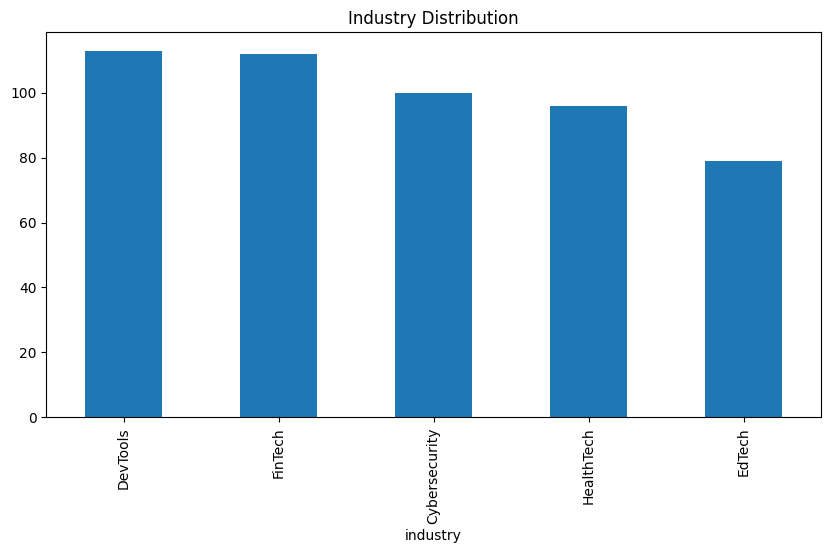

In [30]:
accounts["industry"].value_counts().plot.bar(figsize=(10,5), title="Industry Distribution")

In [31]:
accounts["country"].value_counts()

,count
country,
US,291
UK,58
IN,49
AU,32
DE,25
CA,23
FR,22


In [32]:
accounts["plan_tier"].value_counts()

,count
plan_tier,
Pro,178
Basic,168
Enterprise,154


In [35]:
accounts["status"].value_counts()

,count
is_trial,
False,403
True,97


In [36]:
accounts["churn_flag"].value_counts()

,count
churn_flag,
False,390
True,110


In [37]:
subscriptions["billing_frequency"].value_counts()

,count
billing_frequency,
monthly,2539
annual,2461


In [40]:
subscriptions["mrr_amount"].describe()

,mrr_amount
count,"5,000.00"
mean,"2,267.75"
std,"3,421.38"
min,0.00
25%,285.00
50%,931.00
75%,"2,786.00"
max,"33,830.00"


<Axes: >

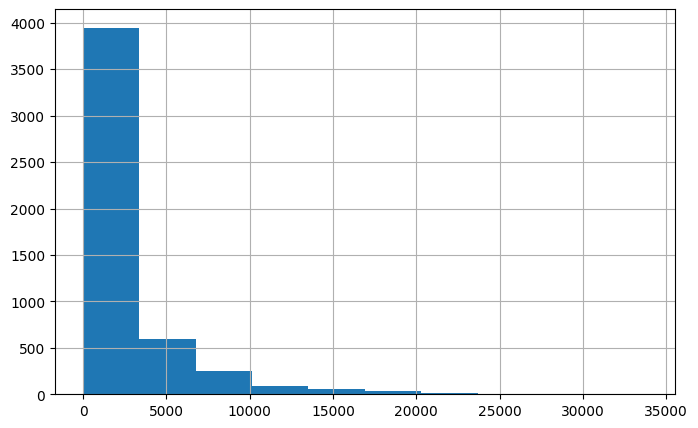

In [41]:
subscriptions["mrr_amount"].hist(figsize=(8,5))


In [43]:
feature_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [44]:
feature_usage["feature_name"].value_counts()

,count
feature_name,
feature_12,659
feature_32,659
feature_6,655
feature_17,651
feature_34,650
...,...
feature_19,589
feature_18,588
feature_35,587


In [46]:
feature_usage["is_beta_feature"].value_counts()

,count
is_beta_feature,
False,22456
True,2544


In [48]:
support_ticket.head(

)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.00,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.00,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.00,urgent,93,4.00,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.00,medium,126,5.00,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.00,medium,8,NaN,False


In [49]:
support_ticket["priority"].value_counts()

,count
priority,
urgent,514
high,510
medium,491
low,485


In [50]:
support_ticket["resolution_time_hours"].value_counts()

,count
resolution_time_hours,
5.00,41
19.00,38
12.00,38
50.00,36
1.00,36
...,...
72.00,21
39.00,18
46.00,17


In [52]:
support_ticket["satisfaction_score"].value_counts()

,count
satisfaction_score,
4.00,405
3.00,396
5.00,374


In [55]:
churn_events["reason_code"].value_counts()

,count
reason_code,
features,114
support,104
budget,104
unknown,95
competitor,92
pricing,91


In [54]:
churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [57]:
churn_events["refund_amount_usd"].value_counts()

,count
refund_amount_usd,
0.00,458
6.38,2
96.45,1
54.94,1
34.40,1
...,...
15.23,1
86.02,1
104.25,1


In [58]:
churn_events["is_reactivation"].value_counts()

,count
is_reactivation,
False,539
True,61


In [59]:
from numpy._core import numeric
import matplotlib.pyplot as plt
numeric_df = subscriptions.select_dtypes(include="number")
numeric_df.corr()

,seats,mrr_amount,arr_amount
seats,1.00,0.49,0.49
mrr_amount,0.49,1.00,1.00
arr_amount,0.49,1.00,1.00


In [60]:
import seaborn as sns

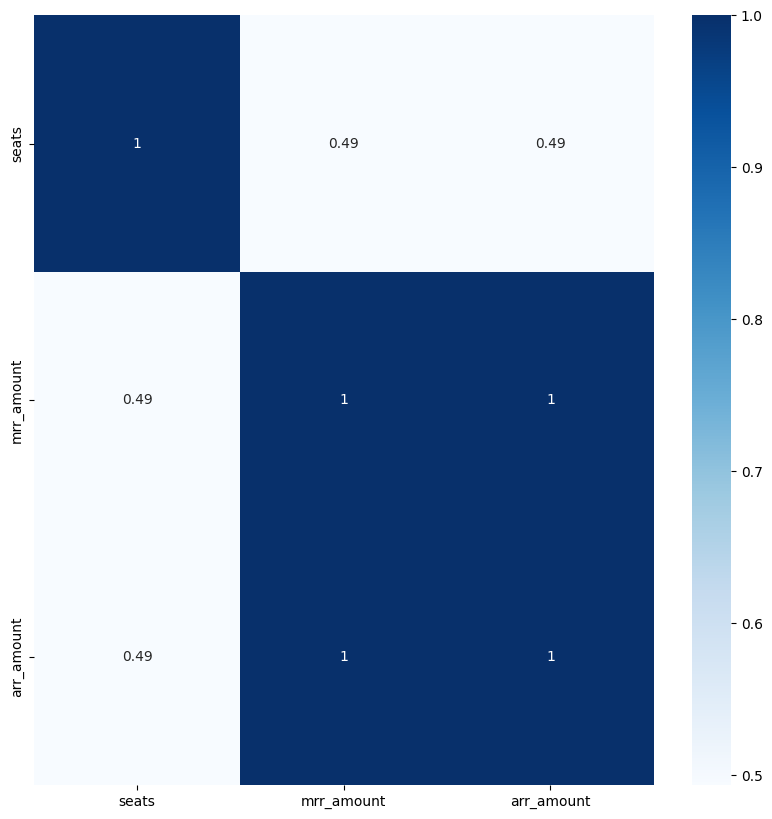

In [61]:
plt.figure(figsize=(10,10))
sns.heatmap(numeric_df.corr(), annot=True,cmap="Blues")
plt.show()